In [1]:
#importing necessary python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller #needed for test for stationarity
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # needed for moving average parameters and autoregressive parameters
from sklearn.metrics import mean_absolute_percentage_error
import warnings

In [7]:
# loading the data into python and naming it's path
df = pd.read_csv("healthcare.csv")

In [8]:
df.info() #checking the details of the dataset in case it needs cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              91 non-null     object
 1   daily_admissions  91 non-null     int64 
 2   daily_discharges  91 non-null     int64 
 3   bed_occupancy     91 non-null     int64 
 4   is_holiday        91 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ KB


In [9]:
df.head()

,date,daily_admissions,daily_discharges,bed_occupancy,is_holiday
0,01/01/2024,168,149,869,0
1,02/01/2024,158,169,858,0
2,03/01/2024,144,165,837,0
3,04/01/2024,172,153,856,0
4,05/01/2024,137,139,854,0


In [10]:
#converting the date column to proper date format
df["date"]= pd.to_datetime(df["date"], format = "%d/%m/%Y", dayfirst = True)

#SARIMA model needs datetime index and the code is coverting the date column as the index of the dataframe
df= df.sort_values("date")
df.set_index("date", inplace = True)
df = df.asfreq("D") # D represents daily data

In [11]:
df.head()

,daily_admissions,daily_discharges,bed_occupancy,is_holiday
date,,,,
2024-01-01,168,149,869,0
2024-01-02,158,169,858,0
2024-01-03,144,165,837,0
2024-01-04,172,153,856,0
2024-01-05,137,139,854,0


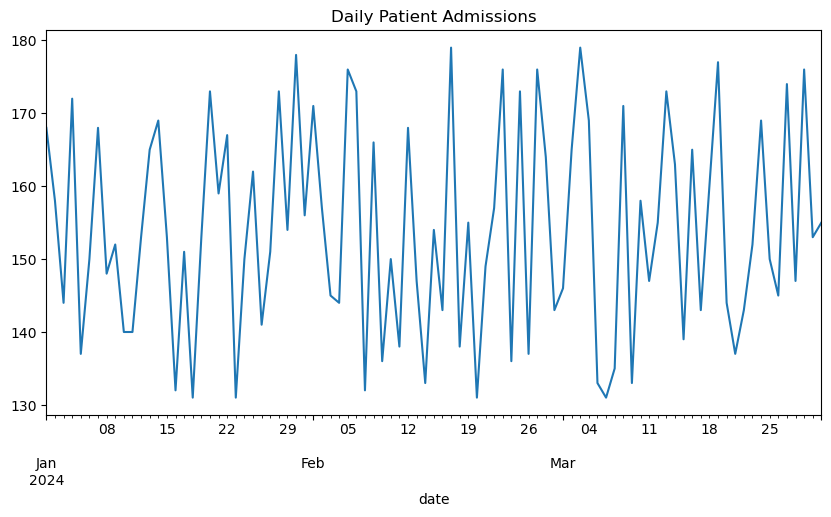

In [12]:
df['daily_admissions'].plot(figsize=(10,5))
plt.title("Daily Patient Admissions")
plt.show()

In [13]:
# testing for stationarity
test_result = adfuller(df['daily_admissions'])

In [14]:
#H0: It is non stationery
#H1: It is stationery

def adfuller_test(daily_admissions):
    result=adfuller(daily_admissions)
    labels = ['ADF test statistics', 'p-value', '#lags used', 'Number of observations used']
    for value, label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1]<= 0.05:
        print("strong evidence against the null hypothesis(H0), reject the null hypothesis . Data has no unit root and is stationary")
    else:
        print("weak eveidence against the null hypothesis, time series has a unit root , indicating it is non-stationary")

In [15]:
adfuller_test(df["daily_admissions"])

ADF test statistics : -6.940191814495508
p-value : 1.0298357909383126e-09
#lags used : 2
Number of observations used : 88
strong evidence against the null hypothesis(H0), reject the null hypothesis . Data has no unit root and is stationary


In [16]:
# checking for seasonal trends
seasonal_diff = df['daily_admissions'].diff(7).dropna()
adf_seasonal = adfuller(seasonal_diff)
print("Seasonal ADF p-value:", adf_seasonal[1])


Seasonal ADF p-value: 0.0007494539258023851


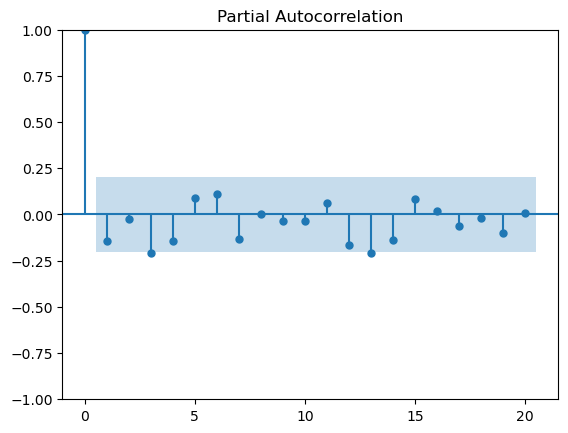

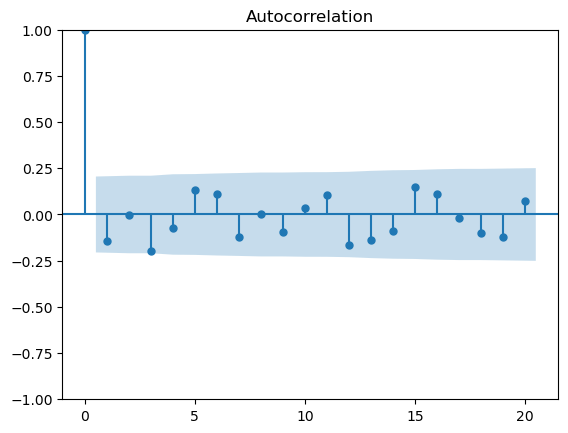

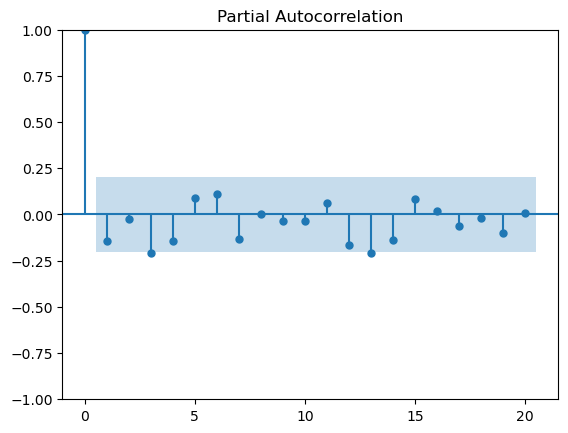

In [18]:
# Calculating the Moving average parameters and Autoregressive parameters
plot_acf(df['daily_admissions'])
plot_pacf(df['daily_admissions'])

In [19]:
# defining the forecasting model
model = SARIMAX(
    df["daily_admissions"],
    order = (0,0,0), # "d" is 0 because the data is stationary and no need for differencing
    seasonal_order = (0,1,0,7) # weekly seasonality
)

In [20]:
# training the model so that python can learn patterns from the data
results = model.fit()
print(results.summary())


                                SARIMAX Results                                
Dep. Variable:        daily_admissions   No. Observations:                   91
Model:             SARIMAX(0, 1, 0, 7)   Log Likelihood                -377.619
Date:                 Thu, 30 Apr 2026   AIC                            757.239
Time:                         18:59:27   BIC                            759.670
Sample:                     01-01-2024   HQIC                           758.216
                          - 03-31-2024                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       470.1438     93.025      5.054      0.000     287.817     652.470
Ljung-Box (L1) (Q):                   2.20   Jarque-Bera (JB):                 2.47
Prob(Q):                              0

In [23]:
# forecasting future patient admissions and predicting
forecast = results.get_forecast(steps=14) # predict the next 14 days
forecast_mean = forecast.predicted_mean

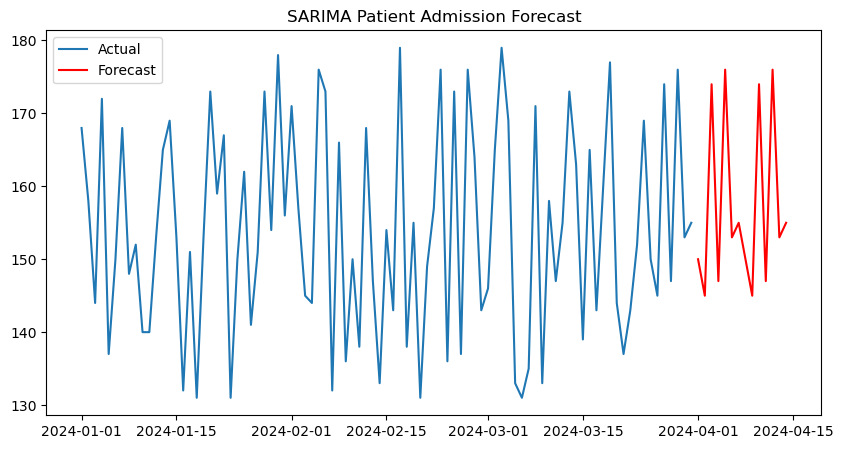

In [24]:
# plotting the real or actual data with the the prediction data
plt.figure(figsize=(10,5))
plt.plot(df['daily_admissions'], label='Actual')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.legend()
plt.title("SARIMA Patient Admission Forecast")
plt.show()


In [25]:
df.isna().sum()

daily_admissions    0
daily_discharges    0
bed_occupancy       0
is_holiday          0
dtype: int64

In [26]:
# Generate forecast values for the same length as the test data
forecast = results.get_forecast(steps=len("test")).predicted_mean


# Check the type of the forecast output (should be a pandas Series)
print(type(forecast))

# Display the first few forecasted values
print(forecast.head())


<class 'pandas.core.series.Series'>
2024-04-01    150.0
2024-04-02    145.0
2024-04-03    174.0
2024-04-04    147.0
Freq: D, Name: predicted_mean, dtype: float64


In [27]:
# Extract the true (actual) values for the forecast period
y_true = df['daily_admissions'].values[-len(forecast):]

# Extract the predicted values from the forecast
y_pred = forecast.values


In [29]:
# Import mean squared error function from sklearn
from sklearn.metrics import mean_squared_error

# Calculate Root Mean Squared Error (RMSE)
# RMSE shows how far predictions are from actual values (lower is better)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)


RMSE: 19.20286436967152


In [30]:
# Calculate model accuracy using RMSE and mean of actual values
# This converts error into a percentage-based accuracy score
accuracy = 100 * (1 - rmse / y_true.mean())
print("Model Accuracy:", accuracy)

Model Accuracy: 87.82702734093724


## CALCULATING MEAN ACTUAL ERROR

In [31]:
## Splitting data into train and test
train = df['daily_admissions'][:-14]
test = df['daily_admissions'][-14:]

## Fitting SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 7))

results = model.fit()

## Forecast
forecast = results.get_forecast(steps=14)
predicted = forecast.predicted_mean

In [32]:
## Calculate MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, predicted)

print("MAE:", mae)

MAE: 10.320729857764604


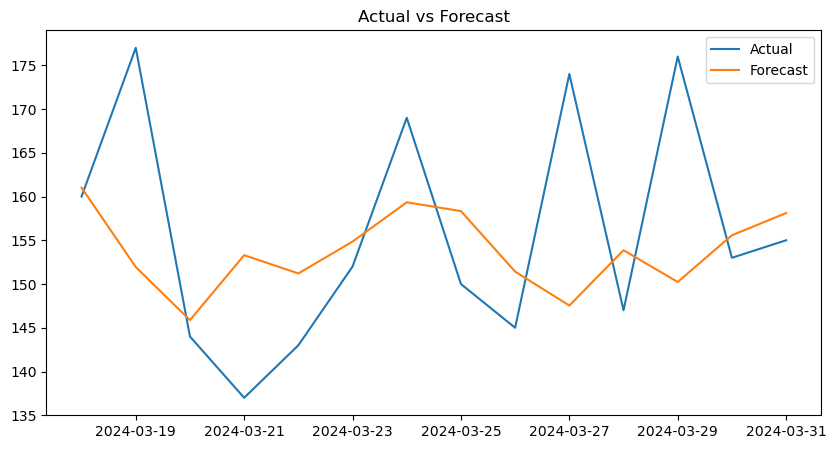

In [36]:
## Visualization of Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test, label='Actual')
plt.plot(predicted, label='Forecast')
plt.legend()
plt.title("Actual vs Forecast")
plt.show()

plt.savefig("forecast.png")

<Figure size 640x480 with 0 Axes>

## Bed_occupancy Analyze

In [43]:
# Calculating bed occupancy rate, minimum bed occupancy is 835 and maximum is 950
Total_bed = 1000
df['bed_occupancy_rate'] = (df['bed_occupancy'] / Total_bed) * 100
df.head()

,daily_admissions,daily_discharges,bed_occupancy,is_holiday,bed_occupancy_rate
date,,,,,
2024-01-01,168,149,869,0,86.9
2024-01-02,158,169,858,0,85.8
2024-01-03,144,165,837,0,83.7
2024-01-04,172,153,856,0,85.6
2024-01-05,137,139,854,0,85.4


In [45]:
# filtering the date dataframe
latest_date = df.index.max()
one_year_ago = latest_date - pd.DateOffset(years=1)

df_last_year = df[df.index >= one_year_ago]


In [46]:
# Overall performance of the hospital using the bed_occupancy rate
df_last_year['bed_occupancy_rate'].describe()

count    91.000000
mean     92.058242
std       2.981240
min      83.500000
25%      90.150000
50%      92.700000
75%      94.850000
max      95.000000
Name: bed_occupancy_rate, dtype: float64

In [49]:
# Create a monthly bed occupancy trend using the DateTime index instead of a date column
monthly_trend = (
    df_last_year
        .groupby(df_last_year.index.to_period('M'))['bed_occupancy_rate']
        .mean()
)
print(monthly_trend)


date
2024-01    91.154839
2024-02    92.800000
2024-03    92.267742
Freq: M, Name: bed_occupancy_rate, dtype: float64


In [50]:
# bed occupancy by holiday trend
df_last_year.groupby('is_holiday')['bed_occupancy_rate'].mean()

is_holiday
0    91.669643
1    92.680000
Name: bed_occupancy_rate, dtype: float64

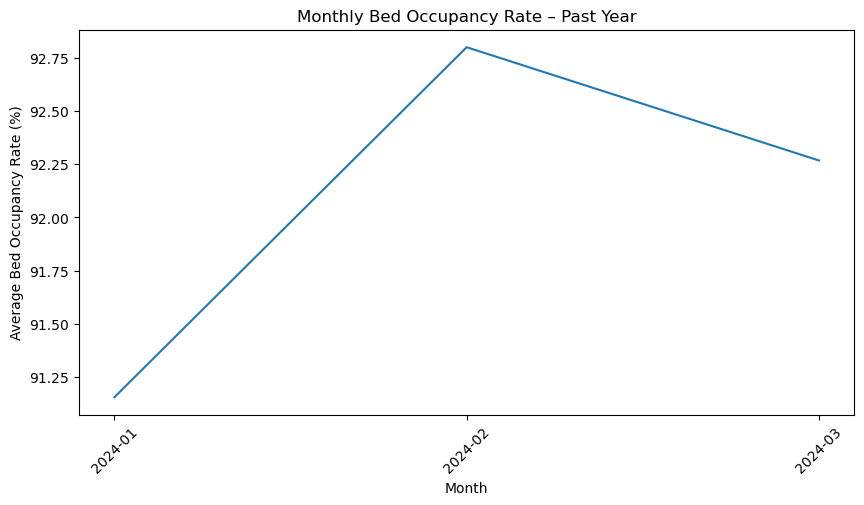

In [52]:
# Visualiation

plt.figure(figsize= (10,5))
plt.plot(monthly_trend.index.astype(str), monthly_trend.values)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Bed Occupancy Rate (%)")
plt.title("Monthly Bed Occupancy Rate – Past Year")
plt.show()


##    REPORT ON BED OCCUPANCY RATE

## Objective :

To analyze bed occupancy trends over the past year to support effective hospital resource management.


 ## Methodology :

Used daily hospital admission and bed occupancy data

Assumed a total bed capacity of 1000 beds based on observed maximum occupancy

Calculated bed occupancy rate as a percentage

Aggregated data monthly for trend analysis


## Key Findings :

Average bed occupancy remained above 80%, indicating sustained demand

Peak occupancy periods were observed in certain months, suggesting seasonal pressure

Bed occupancy was higher during holidays, likely due to reduced discharge rates

Conclusion & Recommendations

Persistent high occupancy suggests the need for contingency planning

Staffing and bed capacity should be strengthened during peak months

Elective admissions should be scheduled during lower-occupancy periods